<a href="https://colab.research.google.com/github/abhinandan-084/pytorch-tutorials/blob/main/02_Continous_XOR_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Imports & Setup

In [1]:
## Standard libraries
import os
import math
import numpy as np
import time

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # For export
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set()

## Progress bar
from tqdm.notebook import tqdm

/tmp/ipykernel_926/47578708.py:11: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf') # For export


In [2]:
# Torch Basics
import torch
print("Using torch", torch.__version__)

# Reproducible Random Numbers
torch.manual_seed(42) # Setting the seed

# Checking GPU Support
gpu_avail = torch.cuda.is_available()
print(f"Is the GPU available? {gpu_avail}")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)

# GPU operations have a separate seed we also want to set
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)

# Additionally, some operations on a GPU are implemented stochastic for efficiency
# We want to ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Using torch 2.10.0+cpu
Is the GPU available? False
Device cpu


 In PyTorch, there is a package called **torch.nn** that makes building neural networks more convenient.

 **XOR Model** :  Given two binary inputs and , the label to predict is if either or is while the other is , or the label is in all other cases. The example became famous by the fact that a single neuron, i.e. a linear classifier, cannot learn this simple function. Hence, we will build a small neural network that can learn this function. To make it a little bit more interesting, we move the XOR into continuous space and introduce some gaussian noise on the binary inputs.

In [3]:
import torch.nn as nn
import torch.nn.functional as F

In PyTorch, a neural network is built up out of modules. Modules can contain other modules, and a neural network is considered to be a module itself as well.

The **MyModule class** inherits from **torch.nn.Module** because it is the base class for all neural network modules in PyTorch. Inheriting from nn.Module provides several crucial functionalities and benefits:

* **Parameter Management**: nn.Module automatically tracks all trainable parameters (like weights and biases in nn.Linear layers) that are defined as attributes within the module. This makes it easy to access and update these parameters during training.
* **Submodule Management**: When you define other nn.Module instances (like nn.Linear or nn.Tanh in SimpleClassifier) as attributes, the parent nn.Module automatically registers them as submodules. This allows for hierarchical network structures and proper handling of parameters across the entire network.
Device Transfer: It enables easy movement of the entire model (including all its parameters and submodules) to different devices, such as a GPU (.to(device)).
* **forward Method**: The forward method is where the computation of the module is defined. When you call an instance of an nn.Module (e.g., model(x)), it automatically executes its forward method.
* **Hooks**: nn.Module provides hooks that allow you to customize the behavior of your model during forward and backward passes, which is useful for debugging, visualization, or custom optimizations.

*In essence, nn.Module acts as a blueprint for building neural networks in PyTorch, streamlining the process of creating, managing, and training complex models.*

The basic template of a module is as follows:

In [4]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        # Some init for my module

    def forward(self, x):
        # Function for performing the calculation of the module.
        pass

### Simple Classifier XOR Model

#### **Section 1 : Model Building**

small_neural_network.svg

In [5]:
class SimpleClassifier(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()
        # Initialize the modules we need to build the network
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.act_fn = nn.Tanh()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # Perform the calculation of the model to determine the prediction
        x = self.linear1(x)
        x = self.act_fn(x)
        x = self.linear2(x)
        return x

In [6]:
# Defining a model
model = SimpleClassifier(num_inputs=2, num_hidden=4, num_outputs=1)
# Printing a module shows all its submodules
print(model)

SimpleClassifier(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (act_fn): Tanh()
  (linear2): Linear(in_features=4, out_features=1, bias=True)
)


Printing the model lists all submodules it contains. The parameters of a module can be obtained by using its parameters() functions, or named_parameters() to get a name to each parameter object. For our small neural network, we have the following parameters:

In [10]:
for name, param in model.named_parameters():
    print(f"Parameter {name}, shape {param.shape}")

Parameter linear1.weight, shape torch.Size([4, 2])
Parameter linear1.bias, shape torch.Size([4])
Parameter linear2.weight, shape torch.Size([1, 4])
Parameter linear2.bias, shape torch.Size([1])


#### **Section 2 : Data Loading**

The data package defines two classes which are the standard interface for handling data in PyTorch: **data.Dataset, and data.DataLoader**.

The dataset class provides an uniform interface to access the training/test data, while the data loader makes sure to efficiently load and stack the data points from the dataset into batches during training.

In [11]:
import torch.utils.data as data

**The dataset class**

The dataset class summarizes the basic functionality of a dataset in a natural way. To define a dataset in PyTorch, we simply specify two functions: __getitem__, and __len__. The get-item function has to return the -th data point in the dataset, while the len function returns the size of the dataset. For the XOR dataset, we can define the dataset class as follows:

In [30]:
class XORDataset(data.Dataset):
    def __init__(self, size, std=0.1):
        """
        Inputs:
            size - Number of data points we want to generate
            std - Standard deviation of the noise (see generate_continuous_xor function)
        """
        super().__init__()
        self.size = size
        self.std = std
        self.generate_continuous_xor()

    def generate_continuous_xor(self):
        # Each data point in the XOR dataset has two variables, x and y, that can be either 0 or 1
        # The label is their XOR combination, i.e. 1 if only x or only y is 1 while the other is 0.
        # If x=y, the label is 0.
        data = torch.randint(low=0, high=2, size=(self.size, 2), dtype=torch.float32)
        label = (data.sum(dim=1) == 1).to(torch.long)
        # To make it slightly more challenging, we add a bit of gaussian noise to the data points.
        data += self.std * torch.randn(data.shape)

        self.data = data
        self.label = label

    def __len__(self):
        # Number of data point we have. Alternatively self.data.shape[0], or self.label.shape[0]
        return self.size

    def __getitem__(self, idx):
        # Return the idx-th data point of the dataset
        # If we have multiple things to return (data point and label), we can return them as tuple
        data_point = self.data[idx]
        data_label = self.label[idx]
        return data_point, data_label

Size of dataset: 200
Data point 0: (tensor([ 0.9287, -0.0700]), tensor(1))


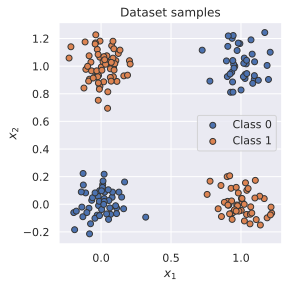

In [33]:
# Let’s try to create such a dataset and inspect it:
dataset = XORDataset(size=200)
print("Size of dataset:", len(dataset))
print("Data point 0:", dataset[0])

# To better relate to the dataset, we visualize the samples below.
def visualize_samples(data, label):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()
    data_0 = data[label == 0]
    data_1 = data[label == 1]

    plt.figure(figsize=(4,4))
    plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label="Class 0")
    plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label="Class 1")
    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

visualize_samples(dataset.data, dataset.label)
plt.show()

**The data loader class**

The dataset class summarizes the